# MPO RPA via Wynn ε-Algorithm

Computes the RPA susceptibility χ_RPA(q,ω) using the Wynn ε-algorithm
applied to scalar observables extracted from the MPO bubble series.

**Key idea:** build bubble MPOs T₀, T₁, ..., T_K; extract scalars
`s_k(q,ω) = −Im ⟨q|S_k(ω)|q⟩/π` at each order; apply Wynn ε per (q,ω).
No MPO inverse is ever computed.


In [9]:
using LinearAlgebra
using Plots
using Measures
using ITensors
using ITensorMPS
using Printf
using Quantics
using QuanticsTCI
using QuanticsGrids
using TensorCrossInterpolation
using TCIITensorConversion
using Statistics

include("../src/CMTensor.jl")


Main.CMTensor

## System Setup

In [33]:
L       = 5
L_chain = 2^L
N       = L_chain

sites  = siteinds("S=1/2", L)
sites2 = siteinds("S=1/2", L)

H  = CMTensor.kinetic_1d_nn(L, sites)
H2 = CMTensor.kinetic_1d_nn(L, sites2)

Tn_list1, Tn_list2, Tn_listeff = CMTensor.get_Tnlists(
    H/6, H2/6, sites, sites2, 100; a=6, maxdim=80)

finalsites      = siteinds("S=1/2", 2L)
finalfinalsites = siteinds("S=1/2", L)


5
5
5
6
5
6
6
6
6
6
6
7
8
7
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
11
10
11
11
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
5
5
5
6
5
6
6
6
6
6
6
7
8
7
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
11
10
11
11
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
13
21
25
29
36
46
55
57
61
66
70
72
75
79
79
79
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80


5-element Vector{Index{Int64}}:
 (dim=2|id=15|"S=1/2,Site,n=1")
 (dim=2|id=27|"S=1/2,Site,n=2")
 (dim=2|id=224|"S=1/2,Site,n=3")
 (dim=2|id=876|"S=1/2,Site,n=4")
 (dim=2|id=320|"S=1/2,Site,n=5")

## Interaction Potential

MPS COMPUTED!
Turned into MPO!
GOT FT TTs
GOT MPO


┌ Warning: Calling `inner(x::MPS, A::MPO, y::MPS)` where the site indices of the `MPS`
│ `x` and the `MPS` resulting from contracting `MPO` `A` with `MPS` `y` don't
│ match is deprecated as of ITensors v0.3 and will result in an error in ITensors
│ v0.4. The most common cause of this is something like the following:
│ 
│ ```julia
│ s = siteinds("S=1/2")
│ psi = random_mps(s)
│ H = MPO(s, "Id")
│ inner(psi, H, psi)
│ ```
│ 
│ `psi` has the Index structure `-s-(psi)` and `H` has the Index structure
│ `-s'-(H)-s-`, so the Index structure of would be `(dag(psi)-s- -s'-(H)-s-(psi)`
│  unless the prime levels were fixed. Previously we tried fixing the prime level
│   in situations like this, but we will no longer be doing that going forward.
│ 
│ There are a few ways to fix this. You can simply change:
│ 
│ ```julia
│ inner(psi, H, psi)
│ ```
│ 
│ to:
│ 
│ ```julia
│ inner(psi', H, psi)
│ ```
│ 
│ in which case the Index structure will be `(dag(psi)-s'-(H)-s-(psi)`.
│ 
│ Alternatively, you c

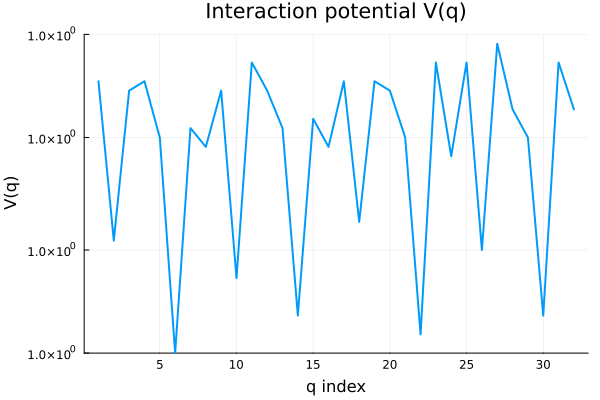

GKS: Possible loss of precision in routine SET_WINDOW


In [4]:
# 1D Coulomb-like potential V(i,j) = 1/|i-j| with small regularisation
function V1d(i, j)
    return 1.0 / (abs(i - j) + 1e-4)
end

function V1d(i, j)
    if i == j
        return 1.0
    else
        return 0.0
    end
end

MPOV = CMTensor.hopping2MPO(V1d, N, finalfinalsites; tol=1e-8, type=ComplexF64)

Vq = CMTensor.get_spect_k(MPOV)
plot(real.(Vq); xlabel="q index", ylabel="V(q)",
    title="Interaction potential V(q)", label=false, lw=2)


## Helper Functions

In [5]:
"""Build the χ₀(omega) bubble MPO on finalfinalsites."""
function build_bubble_mpo(
    ω;
    Tn_list1, Tn_list2, Tn_listeff,
    sites, sites2, finalsites, finalfinalsites,
    Nc=79, sign=-1, a=6, maxdim=200,
)
    bubble = CMTensor.get_bublle_expanded_from_Tn(
        Tn_list1, Tn_list2, Tn_listeff,
        sites, sites2, Nc, ω, sign; a=a, maxdim=maxdim,
    )
    bubble_interleaved = CMTensor.swap_every_other_legs(bubble, finalsites)
    return CMTensor.collapse_mpo_pairs(bubble_interleaved, finalfinalsites)
end

"""
Wynn ε-algorithm applied to a scalar sequence s = [s₀, s₁, ..., s_K].
Returns Padé estimates [ε₂(0), ε₄(0), ...] (even columns, first row).
Uses only additions and reciprocals -- no matrix operations.
"""
function wynn_epsilon(s::AbstractVector)
    n   = length(s)
    eps = zeros(ComplexF64, n+1, n+1)
    for k in 1:n
        eps[2, k] = s[k]      # ε₀(k-1) = s_k
    end
    for j in 1:n-1
        for k in 1:n-j
            d = eps[j+1, k+1] - eps[j+1, k]
            eps[j+2, k] = abs(d) < 1e-30 ? complex(1e30) : eps[j, k+1] + 1/d
        end
    end
    return [real(eps[j+2, 1]) for j in 2:2:n-1]   # ε₂(0), ε₄(0), ...
end


wynn_epsilon

## Build Bubble Terms T₀, T₁, ..., T_K

For each frequency ω, build the MPO bubble terms:
- T₀ = χ₀(ω)
- Tₙ = Tₙ₋₁ · V · χ₀   (i.e. Tₙ = (χ₀ V)ⁿ χ₀)

At each order n, extract `vₙ(q) = get_spect_k(Tₙ)[q]` for all q.
This is a cheap MPO contraction -- no MPO sums or inverses.


In [6]:
ωlist = range(0.0, 4.0; length=50)
nω    = length(ωlist)
ωax   = collect(ωlist)
K_max  = 6     # number of bubble orders beyond χ₀ (total K_max+1 terms)
maxdim_apply = 200
cutoff_apply = 1e-8

# spect_terms[n+1, i_ω, q] = −Im get_spect_k(Tₙ)[q]  (contribution of term n)
spect_terms = nothing   # allocated on first ω

for (i, ω) in enumerate(ωlist)
    χ0 = build_bubble_mpo(ω;
        Tn_list1=Tn_list1, Tn_list2=Tn_list2, Tn_listeff=Tn_listeff,
        sites=sites, sites2=sites2,
        finalsites=finalsites, finalfinalsites=finalfinalsites,
    )

    term = deepcopy(χ0)   # T₀ = χ₀

    v0 = -imag.(CMTensor.get_spect_k(term))
    if spect_terms === nothing
        nq = length(v0)
        spect_terms = zeros(Float64, K_max+1, nω, nq)
    end
    spect_terms[1, i, :] = v0   # n=0

    for n in 1:K_max
        term = apply(term, MPOV; maxdim=maxdim_apply, cutoff=cutoff_apply)
        term = apply(term, χ0;   maxdim=maxdim_apply, cutoff=cutoff_apply)
        spect_terms[n+1, i, :] = -imag.(CMTensor.get_spect_k(term))
    end

    @printf("ω %d / %d done\n", i, nω)
end

nq = size(spect_terms, 3)
@printf("Done. spect_terms shape: (%d, %d, %d)\n", K_max+1, nω, nq)


Got P1
Got P2
got ids
Got numerator
Got GF
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
ω 1 / 50 done
Got P1
Got P2
got ids
Got numerator
Got GF
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
ω 2 / 50 done
Got P1
Got P2
got ids
Got numerator
Got GF
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
ω 3 / 50 done
Got P1
Got P2
got ids
Got numerator
Got GF
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
ω 4 / 50 done
Got P1
Got P2
got ids
Got numerator
Got GF
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
GOT FT TTs
GOT MPO
ω 5 / 50 done
Got P1
Got P2
got ids
Got numerator
Got GF
GOT FT 

## Wynn ε-Acceleration

For each (q, ω) accumulate the partial sum sequence
`s_k(q,ω) = ∑ₙ₌₀ᵏ spect_terms[n, ω, q]`
and apply Wynn ε to get Padé estimates ε₂, ε₄, ...


In [7]:
n_wynn = K_max ÷ 2   # number of Wynn Padé estimates

# partial sums: chi_kw_partial[k+1, i_ω, q] = s_k(q,ω)
chi_kw_partial = cumsum(spect_terms; dims=1)

# Wynn estimates: chi_kw_wynn[m, i_ω, q] = ε_{2m}(0)
chi_kw_wynn = zeros(Float64, n_wynn, nω, nq)

for i in 1:nω, q in 1:nq
    seq  = chi_kw_partial[:, i, q]   # length K_max+1
    ests = wynn_epsilon(complex.(seq))
    for m in 1:min(n_wynn, length(ests))
        chi_kw_wynn[m, i, q] = ests[m]
    end
end

@printf("Wynn done. %d Padé estimates per (q,ω) point.\n", n_wynn)


Wynn done. 3 Padé estimates per (q,ω) point.


## Results: χ₀ and Partial Sums

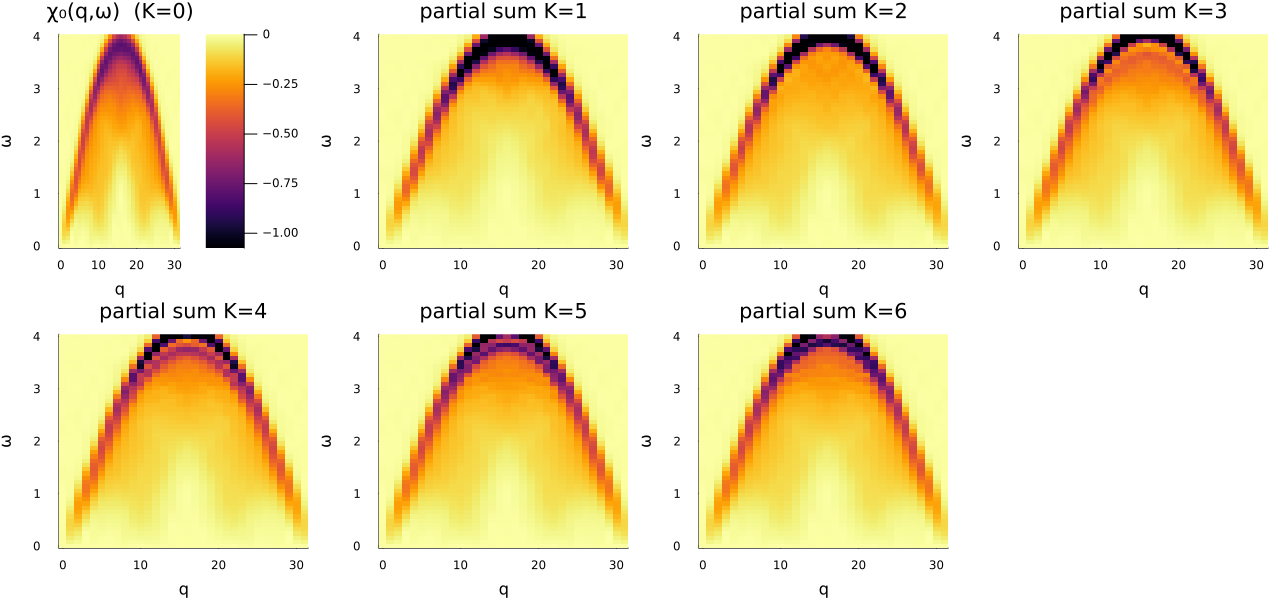

In [29]:
all_partial = vec(chi_kw_partial)
cl_lo = quantile(all_partial, 0.01)
cl_hi = quantile(all_partial, 0.99)

# χ₀
p_chi0 = heatmap(0:nq-1, ωax, chi_kw_partial[1,:,:];
    title="χ₀(q,ω)  (K=0)", xlabel="q", ylabel="ω",
    color=:inferno, clims=(cl_lo, cl_hi))

# partial sums K=1,...,K_max
p_partial = [heatmap(0:nq-1, ωax, chi_kw_partial[k+1,:,:];
    title="partial sum K=$(k)", xlabel="q", ylabel="ω",
    color=:inferno, clims=(cl_lo, cl_hi),
    colorbar=false) for k in 1:K_max]

display(plot(p_chi0, p_partial...;
    layout=(2, ceil(Int, (K_max+1)/2)),
    size=(ceil(Int, (K_max+1)/2)*320, 600),
    left_margin=4mm, bottom_margin=4mm, top_margin=3mm))


## Results: Wynn ε-Acceleration

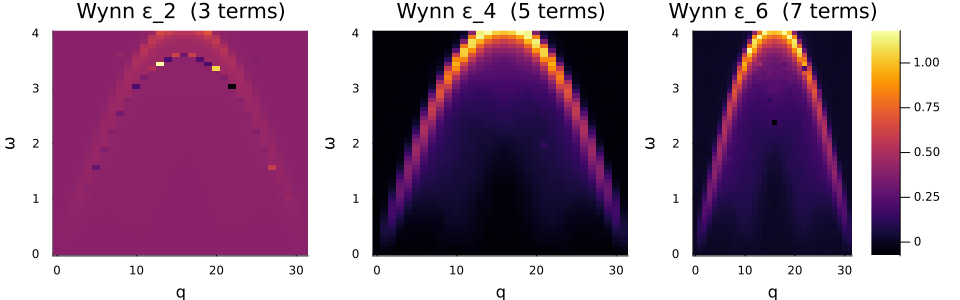

In [31]:
# shared color limits across all Wynn panels
cl_lo_w = quantile(vec(-chi_kw_wynn), 0.01)
cl_hi_w = quantile(vec(-chi_kw_wynn), 0.99)

wynn_panels = Any[]
for m in 1:n_wynn
    push!(wynn_panels, heatmap(0:nq-1, ωax, -chi_kw_wynn[m,:,:];
        title="Wynn ε_$(2m)  ($(2m+1) terms)",
        xlabel="q", ylabel="ω",
        color=:inferno,
        colorbar=(m == n_wynn)))
end

ncols = min(n_wynn, 3)
nrows = ceil(Int, n_wynn / ncols)
display(plot(wynn_panels...;
    layout=(nrows, ncols),
    size=(ncols*320, nrows*300),
    left_margin=4mm, bottom_margin=4mm, top_margin=3mm))


## Comparison: Partial Sum vs Wynn at Same K

The Wynn ε₂ estimate uses 3 terms and should already be close to the
converged result. Compare it directly with the raw partial sum at K=2.


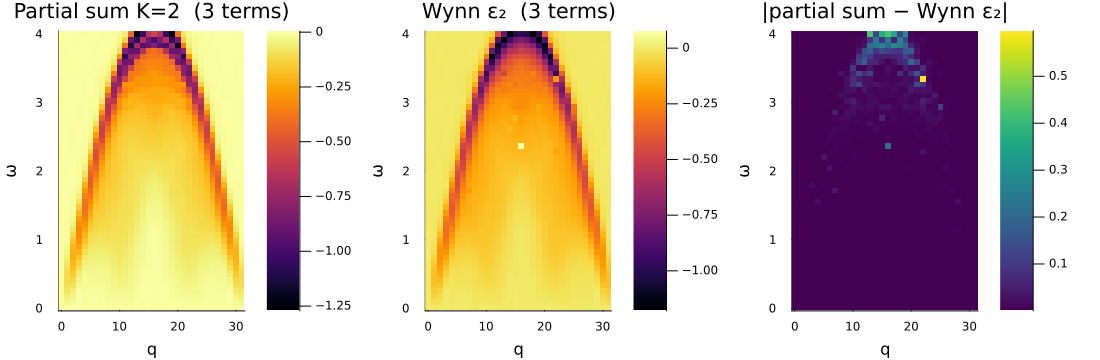

In [28]:
# use K=2 partial sum and ε₂ (both use 3 terms)
data_sum = chi_kw_partial[7, :, :]    # K=2 partial sum
data_w2  = chi_kw_wynn[3, :, :]       # ε₂

all_d = vcat(vec(data_sum), vec(data_w2))
c_lo, c_hi = quantile(all_d, 0.02), quantile(all_d, 0.98)

p_s2 = heatmap(0:nq-1, ωax, data_sum;
    title="Partial sum K=2  (3 terms)",
    xlabel="q", ylabel="ω", color=:inferno)
p_w2 = heatmap(0:nq-1, ωax, data_w2;
    title="Wynn ε₂  (3 terms)",
    xlabel="q", ylabel="ω", color=:inferno)
p_diff = heatmap(0:nq-1, ωax, abs.(data_sum .- data_w2);
    title="|partial sum − Wynn ε₂|",
    xlabel="q", ylabel="ω", color=:viridis)

display(plot(p_s2, p_w2, p_diff;
    layout=(1, 3), size=(1100, 360),
    left_margin=5mm, bottom_margin=5mm, top_margin=3mm))


## Convergence at a Fixed q Point

Pick the q index with the strongest spectral weight in the Wynn ε₂ result
and plot the partial sum vs Wynn convergence as a function of K.


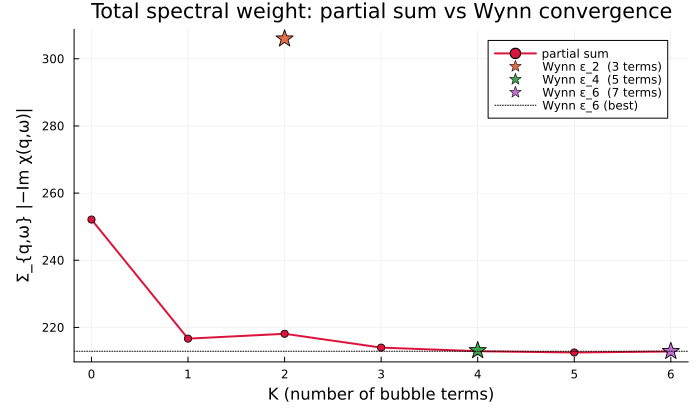

In [32]:
# Convergence summed over all (q, ω)
# For each order k, compute the total spectral weight Σ_{q,ω} |s_k(q,ω)|
# and compare with the Wynn ε estimates at the same number of terms.

# partial sum total weight at each order k
spec_partial_total = [sum(abs.(chi_kw_partial[k+1, :, :])) for k in 0:K_max]

# Wynn total weight at each estimate m
spec_wynn_total = [sum(abs.(chi_kw_wynn[m, :, :])) for m in 1:n_wynn]

p_conv = plot(0:K_max, spec_partial_total;
    label="partial sum", lw=2, marker=:circle, color=:crimson,
    xlabel="K (number of bubble terms)",
    ylabel="Σ_{q,ω} |−Im χ(q,ω)|",
    title="Total spectral weight: partial sum vs Wynn convergence")
for m in 1:n_wynn
    # ε_{2m} first available after 2m+1 terms, plotted at K=2m
    scatter!(p_conv, [2m], [spec_wynn_total[m]];
        label="Wynn ε_$(2m)  ($(2m+1) terms)",
        markersize=9, markershape=:star5)
end
hline!(p_conv, [spec_wynn_total[end]];
    lw=1, ls=:dot, color=:black, label="Wynn ε_$(2*n_wynn) (best)")

display(plot(p_conv; size=(700, 420),
    left_margin=5mm, bottom_margin=5mm))
